# Lab: Linear Models and Regularization Methods

In [12]:
import numpy as np
import pandas as pd
from matplotlib.pyplot import subplots
from statsmodels.api import OLS
import sklearn.model_selection as skm
import sklearn.linear_model as skl
from sklearn.preprocessing import StandardScaler
from ISLP import load_data
from ISLP.models import ModelSpec as MS
from functools import partial

In [4]:
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.cross_decomposition import PLSRegression
from ISLP.models import (Stepwise,
                         sklearn_selected,
                         sklearn_selection_path)
from l0bnb import fit_path

## Subset Selection Methods

### Forward Selection

In [6]:
hitters = load_data('Hitters')
hitters.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 322 entries, 0 to 321
Data columns (total 20 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   AtBat      322 non-null    int64   
 1   Hits       322 non-null    int64   
 2   HmRun      322 non-null    int64   
 3   Runs       322 non-null    int64   
 4   RBI        322 non-null    int64   
 5   Walks      322 non-null    int64   
 6   Years      322 non-null    int64   
 7   CAtBat     322 non-null    int64   
 8   CHits      322 non-null    int64   
 9   CHmRun     322 non-null    int64   
 10  CRuns      322 non-null    int64   
 11  CRBI       322 non-null    int64   
 12  CWalks     322 non-null    int64   
 13  League     322 non-null    category
 14  Division   322 non-null    category
 15  PutOuts    322 non-null    int64   
 16  Assists    322 non-null    int64   
 17  Errors     322 non-null    int64   
 18  Salary     263 non-null    float64 
 19  NewLeague  322 non-null    ca

we can see that some of the cells are missing salary data


In [7]:
np.isnan(hitters['Salary']).sum()

np.int64(59)

In [9]:
hitters = hitters.dropna();
# it drops all the rows that have a missing value
hitters.shape

(263, 20)

We chose the best model using forward selection $C_{p}$. This is not built in sklearn so we code it by ourself. By, def sklearn tries to max a score so we compute the negative $C_{p}$
$$
     C_{p} = \frac{1}{n} (RSS + 2d\hat{\sigma}^{2})
$$

In [10]:
def nCp(sigma2, estimator, X, Y):
    'Negative Cp statistic'
    n, p = X.shape
    Yhat = estimator.predict(X)
    RSS = np.sum((Y - Yhat)**2)
    return -(RSS + 2*p*sigma2) / n

In [ ]:
design = MS(hitters.columns.drop('Salary')).fit(hitters)
Y = np.array(hitters['Salary'])
X = design.transform(hitters)
sigma2 = OLS(Y,X).fit().scale
sigma2

np.float64(99591.35617968219)

here scale returns estimated variance $\hat{\sigma}^{2}$ of the residuals

In [17]:
neg_Cp = partial(nCp, sigma2)

In [18]:
strategy = Stepwise.first_peak(design,
                               direction='forward',
                               max_terms=len(design.terms))

In [19]:
hitters_MSE = sklearn_selected(OLS,
                               strategy)
hitters_MSE.fit(hitters, Y)
hitters_MSE.selected_state_

('Assists',
 'AtBat',
 'CAtBat',
 'CHits',
 'CHmRun',
 'CRBI',
 'CRuns',
 'CWalks',
 'Division',
 'Errors',
 'Hits',
 'HmRun',
 'League',
 'NewLeague',
 'PutOuts',
 'RBI',
 'Runs',
 'Walks',
 'Years')

In [20]:
hitters_Cp = sklearn_selected(OLS,
                              strategy,
                              scoring=neg_Cp)
hitters_Cp.fit(hitters, Y)
hitters_Cp.selected_state_

('Assists',
 'AtBat',
 'CAtBat',
 'CRBI',
 'CRuns',
 'CWalks',
 'Division',
 'Hits',
 'PutOuts',
 'Walks')

### Choosing Among Models Using the Validation Set Approach and Cross-Validation

In [22]:
strategy = Stepwise.fixed_steps(design,len(design.terms) ,direction='forward')
full_path = sklearn_selection_path(OLS, strategy)

In [24]:
full_path.fit(hitters, Y)
Yhat_in = full_path.predict(hitters)
Yhat_in.shape

(263, 20)

(50000.0, 250000.0)

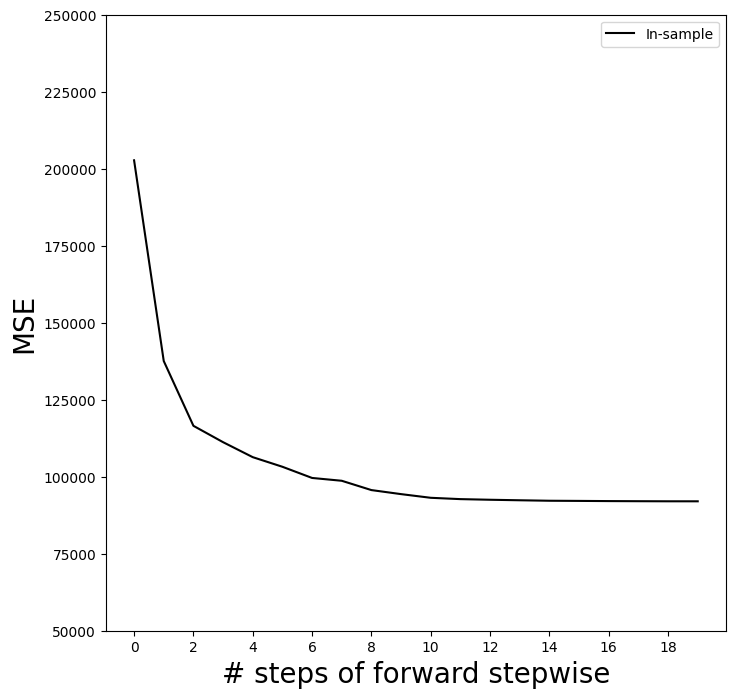

In [25]:
mse_fig, ax = subplots(figsize=(8,8))
insample_mse = ((Yhat_in - Y[:,None])**2).mean(0)
n_steps = insample_mse.shape[0]
ax.plot(np.arange(n_steps),
        insample_mse,
        'k', #colorblack
        label='In-sample')
ax.set_ylabel('MSE',
            fontsize=20)
ax.set_xlabel('# steps of forward stepwise',
                fontsize=20)
ax.set_xticks(np.arange(n_steps)[::2])
ax.legend()
ax.set_ylim([50000,250000])